In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [148]:
df = pd.read_csv(r"C:\Users\User\Downloads\hotel_booking (1).csv")
df.head(3)

,hotel,is_canceled,lead_time,reservation_status_date,stays_in_weekend,stays_in_week,adults,children,babies,meal,...,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,reserved_room_type,booking_changes,customer_type,adr,required_car_parking_spaces,reservation_status
0,Resort Hotel,0,342,7/1/2015,0,0,2,0.0,0,BB,...,Direct,Direct,0,0,C,3,Transient,0.0,0,Check-Out
1,Resort Hotel,0,737,7/1/2015,0,0,2,0.0,0,BB,...,Direct,Direct,0,0,C,4,Transient,0.0,0,Check-Out
2,Resort Hotel,0,7,7/2/2015,0,1,1,0.0,0,BB,...,Direct,Direct,0,0,A,0,Transient,75.0,0,Check-Out


In [150]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'reservation_status_date',
       'stays_in_weekend', 'stays_in_week', 'adults', 'children', 'babies',
       'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations', 'reserved_room_type',
       'booking_changes', 'customer_type', 'adr',
       'required_car_parking_spaces', 'reservation_status'],
      dtype='object')

In [151]:
df.dtypes

hotel                           object
is_canceled                      int64
lead_time                        int64
reservation_status_date         object
stays_in_weekend                 int64
stays_in_week                    int64
adults                           int64
children                       float64
babies                           int64
meal                            object
country                         object
market_segment                  object
distribution_channel            object
is_repeated_guest                int64
previous_cancellations           int64
reserved_room_type              object
booking_changes                  int64
customer_type                   object
adr                            float64
required_car_parking_spaces      int64
reservation_status              object
dtype: object

In [152]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')

In [153]:
df.dtypes

hotel                                  object
is_canceled                             int64
lead_time                               int64
reservation_status_date        datetime64[ns]
stays_in_weekend                        int64
stays_in_week                           int64
adults                                  int64
children                              float64
babies                                  int64
meal                                   object
country                                object
market_segment                         object
distribution_channel                   object
is_repeated_guest                       int64
previous_cancellations                  int64
reserved_room_type                     object
booking_changes                         int64
customer_type                          object
adr                                   float64
required_car_parking_spaces             int64
reservation_status                     object
dtype: object

In [154]:
df.isna().sum()

hotel                            0
is_canceled                      0
lead_time                        0
reservation_status_date          0
stays_in_weekend                 0
stays_in_week                    0
adults                           0
children                         4
babies                           0
meal                             0
country                        488
market_segment                   0
distribution_channel             0
is_repeated_guest                0
previous_cancellations           0
reserved_room_type               0
booking_changes                  0
customer_type                    0
adr                              0
required_car_parking_spaces      0
reservation_status               0
dtype: int64

In [155]:
df['children'] = df['children'].fillna(df['children'].median())

In [156]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [157]:
df.duplicated().sum()

np.int64(33805)

In [158]:
df = df.drop_duplicates()

In [159]:
df.duplicated().sum()

np.int64(0)

In [160]:
df.isnull().sum()

hotel                          0
is_canceled                    0
lead_time                      0
reservation_status_date        0
stays_in_weekend               0
stays_in_week                  0
adults                         0
children                       0
babies                         0
meal                           0
country                        0
market_segment                 0
distribution_channel           0
is_repeated_guest              0
previous_cancellations         0
reserved_room_type             0
booking_changes                0
customer_type                  0
adr                            0
required_car_parking_spaces    0
reservation_status             0
dtype: int64



                                                 ANSWERS OF THE ANALYSIS PARTS



In [161]:
df.head(1)

,hotel,is_canceled,lead_time,reservation_status_date,stays_in_weekend,stays_in_week,adults,children,babies,meal,...,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,reserved_room_type,booking_changes,customer_type,adr,required_car_parking_spaces,reservation_status
0,Resort Hotel,0,342,2015-07-01,0,0,2,0.0,0,BB,...,Direct,Direct,0,0,C,3,Transient,0.0,0,Check-Out


In [162]:
df['total_n_stays'] = df['stays_in_week'] + df['stays_in_weekend']
df['revenue'] = df['adr'] * df['total_n_stays']
df['t_guests'] = df['adults'] + df['children'] + df['babies']


                                                  1)Overall cancellation rate


In [163]:
cancel_rate = (df[df['is_canceled'] == 1]['is_canceled'].count()/df['is_canceled'].count())
print(cancel_rate * 100,'%')

27.920780510603493 %



                                                  2)Cancellation by hotel type



In [164]:
cancel = df[df['is_canceled'] == 1]
cancel.head(2)

,hotel,is_canceled,lead_time,reservation_status_date,stays_in_weekend,stays_in_week,adults,children,babies,meal,...,previous_cancellations,reserved_room_type,booking_changes,customer_type,adr,required_car_parking_spaces,reservation_status,total_n_stays,revenue,t_guests
8,Resort Hotel,1,85,2015-05-06,0,3,2,0.0,0,BB,...,0,A,0,Transient,82.0,0,Canceled,3,246.0,2.0
9,Resort Hotel,1,75,2015-04-22,0,3,2,0.0,0,HB,...,0,D,0,Transient,105.5,0,Canceled,3,316.5,2.0


In [165]:
cancel.groupby('hotel')[['is_canceled']].sum()

,is_canceled
hotel,
City Hotel,15957
Resort Hotel,7939




                        3) Cancellation by lead time (try to group the lead time according to the reference below "0-7                                                     days", "8-30 days", "31-90 days", "91-180 days", "181-365 days", "365+ days")




In [166]:
def lead_category(x):
    if x <= 7:
        return '0-7 days'
    elif x <= 30:
        return '8-30 days'
    elif x <= 90:
        return '31-90 days'
    elif x <= 180:
        return '91-180 days'
    elif x <= 365:
        return '181-365 days'
    else:
        return '365+ days'
df['lead_group'] = df['lead_time'].apply(lead_category)     

In [167]:
df.groupby('lead_group')[['is_canceled']].mean()*100

,is_canceled
lead_group,
0-7 days,8.535909
181-365 days,40.929716
31-90 days,32.506281
365+ days,46.200000
8-30 days,25.604764
91-180 days,35.468698




                                              4)Cancellation by market segment




In [168]:
df.groupby('market_segment')[['is_canceled']].mean().sort_values(by = 'market_segment', ascending = False)*100

,is_canceled
market_segment,
Undefined,100.000000
Online TA,35.494587
Offline TA/TO,15.287339
Groups,30.182232
Direct,14.758161
Corporate,12.431897
Complementary,12.790698
Aviation,19.823789




                                 5)Cancellation by the average daily rate group (you are required to make a new variable called                                                         adr_group, ‘low’, ‘medium’, and ‘high’) so that we understand what adr group the cancellation is                                                      happening from. It may tell us higher priced bookings may have higher cancellation rate or the                                                        medium group or the lower bookings






In [169]:
def adr_category(x):
    if x <= 70:
        return 'Low'
    elif x <= 135:
        return 'Medium'
    else:
        return 'High'
df['adr_category'] = df['adr'].apply(adr_category)        

In [170]:
df.groupby('adr_category')[['is_canceled']].mean().sort_values(by = 'adr_category')*100

,is_canceled
adr_category,
High,34.569435
Low,17.993251
Medium,29.289775





                                                6) Cancellation by customer type




In [171]:
df.groupby('customer_type')[['is_canceled']].mean()*100

,is_canceled
customer_type,
Contract,16.457327
Group,10.018553
Transient,30.237935
Transient-Party,16.564243





                                                  7) Cancellation by room type




In [172]:
df.groupby('reserved_room_type')[['is_canceled']].mean().sort_values(by = 'reserved_room_type', ascending = False)*100

,is_canceled
reserved_room_type,
P,100.000000
L,33.333333
H,40.771812
G,35.902439
F,30.120910
E,27.342447
D,30.269423
C,32.456140
B,31.841302





                                       8)Cancellation by new customer vs repeated guests




In [173]:
def type_of_guest(x):
    if x == 1:
        return 'Repeated_guest'
    else:
        return 'New_customer'
df['type_of_guest'] = df['is_repeated_guest'].apply(type_of_guest)
df.groupby('type_of_guest')[['is_canceled']]. mean() * 100

,is_canceled
type_of_guest,
New_customer,28.734333
Repeated_guest,7.812500





                                            9)Monthly cancellation rate





In [174]:
df['month'] = df['reservation_status_date'].dt.month_name()
df.groupby('month')[['is_canceled']]. mean().sort_values(by = 'is_canceled', ascending = False) * 100

,is_canceled
month,
January,39.129752
February,36.588879
March,32.893262
April,30.291591
December,30.133503
May,28.674909
June,27.561348
November,24.291132
October,23.931234



          
                               10)Monthly revenue (let’s find the trend and see if we have any seasonality)




In [175]:
df.groupby('month')[['revenue']]. sum().sort_values(by = 'revenue', ascending = False) * 100

,revenue
month,
August,542393987.0
July,469443990.0
June,326065590.0
May,320187490.0
April,296623191.0
September,293260495.0
March,262345930.0
February,208619899.0
October,204692643.0


C:\Users\User\AppData\Local\Temp\ipykernel_1548\1830437664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('month')[['revenue']].sum().plot(kind='line')


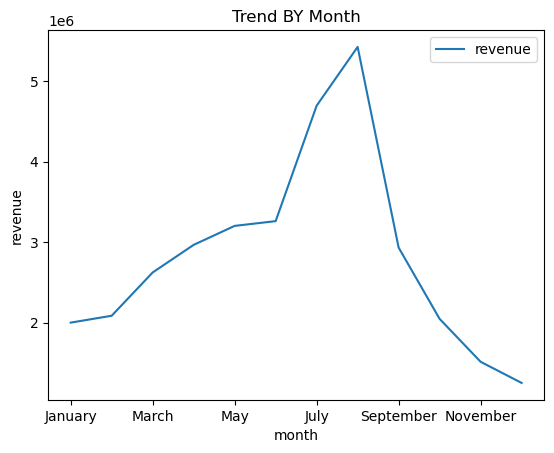

In [177]:
df.groupby('month')[['revenue']].sum().plot(kind='line')
plt.xlabel('month')
plt.ylabel('revenue')
plt.title('Trend BY Month')
plt.show()





              11)Potential revenue lost from cancellation (potential revenue that could come from the cancelled bookings)






In [178]:
cancelation = df[df['is_canceled'] == 1 ]
cancelation.head(3)

,hotel,is_canceled,lead_time,reservation_status_date,stays_in_weekend,stays_in_week,adults,children,babies,meal,...,adr,required_car_parking_spaces,reservation_status,total_n_stays,revenue,t_guests,lead_group,adr_category,type_of_guest,month
8,Resort Hotel,1,85,2015-05-06,0,3,2,0.0,0,BB,...,82.0,0,Canceled,3,246.0,2.0,31-90 days,Medium,New_customer,May
9,Resort Hotel,1,75,2015-04-22,0,3,2,0.0,0,HB,...,105.5,0,Canceled,3,316.5,2.0,31-90 days,Medium,New_customer,April
10,Resort Hotel,1,23,2015-06-23,0,4,2,0.0,0,BB,...,123.0,0,Canceled,4,492.0,2.0,8-30 days,Medium,New_customer,June


In [179]:
revenue_lost = cancelation['adr'] * cancelation['total_n_stays']
print(revenue_lost.sum())

11433962.629999999







12)Build a predictive model to predict the cancellation
(to make it easy: the X features should be identified from the variables;
hotel, lead_time, total_stays, market_segment, is repeated_guest, previous_cancellations, reserved_room_type, customer_type and adr)
(the Y or Target variable is_cancelled)





In [180]:
df['is_canceled'].unique()

array([0, 1])

In [181]:
df.head()

,hotel,is_canceled,lead_time,reservation_status_date,stays_in_weekend,stays_in_week,adults,children,babies,meal,...,adr,required_car_parking_spaces,reservation_status,total_n_stays,revenue,t_guests,lead_group,adr_category,type_of_guest,month
0,Resort Hotel,0,342,2015-07-01,0,0,2,0.0,0,BB,...,0.0,0,Check-Out,0,0.0,2.0,181-365 days,Low,New_customer,July
1,Resort Hotel,0,737,2015-07-01,0,0,2,0.0,0,BB,...,0.0,0,Check-Out,0,0.0,2.0,365+ days,Low,New_customer,July
2,Resort Hotel,0,7,2015-07-02,0,1,1,0.0,0,BB,...,75.0,0,Check-Out,1,75.0,1.0,0-7 days,Medium,New_customer,July
3,Resort Hotel,0,13,2015-07-02,0,1,1,0.0,0,BB,...,75.0,0,Check-Out,1,75.0,1.0,8-30 days,Medium,New_customer,July
4,Resort Hotel,0,14,2015-07-03,0,2,2,0.0,0,BB,...,98.0,0,Check-Out,2,196.0,2.0,8-30 days,Medium,New_customer,July


In [182]:
df.dtypes

hotel                                  object
is_canceled                             int64
lead_time                               int64
reservation_status_date        datetime64[ns]
stays_in_weekend                        int64
stays_in_week                           int64
adults                                  int64
children                              float64
babies                                  int64
meal                                   object
country                                object
market_segment                         object
distribution_channel                   object
is_repeated_guest                       int64
previous_cancellations                  int64
reserved_room_type                     object
booking_changes                         int64
customer_type                          object
adr                                   float64
required_car_parking_spaces             int64
reservation_status                     object
total_n_stays                     

In [185]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['n_hotel'] = le.fit_transform(df['hotel'])
df['n_market_segment'] = le.fit_transform(df['market_segment'])
df['n_reserved_room_type'] = le.fit_transform(df['reserved_room_type'])
df['n_customer_type'] = le.fit_transform(df['customer_type'])


In [186]:
df.dtypes

hotel                                  object
is_canceled                             int64
lead_time                               int64
reservation_status_date        datetime64[ns]
stays_in_weekend                        int64
stays_in_week                           int64
adults                                  int64
children                              float64
babies                                  int64
meal                                   object
country                                object
market_segment                         object
distribution_channel                   object
is_repeated_guest                       int64
previous_cancellations                  int64
reserved_room_type                     object
booking_changes                         int64
customer_type                          object
adr                                   float64
required_car_parking_spaces             int64
reservation_status                     object
total_n_stays                     

In [188]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
X = df[['n_hotel','n_market_segment','n_reserved_room_type','n_customer_type','lead_time','total_n_stays','previous_cancellations','is_repeated_guest','adr']]
y = df['is_canceled']
from sklearn.model_selection import  train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
model.fit(X_train,y_train)
model.score(X_test, y_test)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7275223462055267

<Axes: >

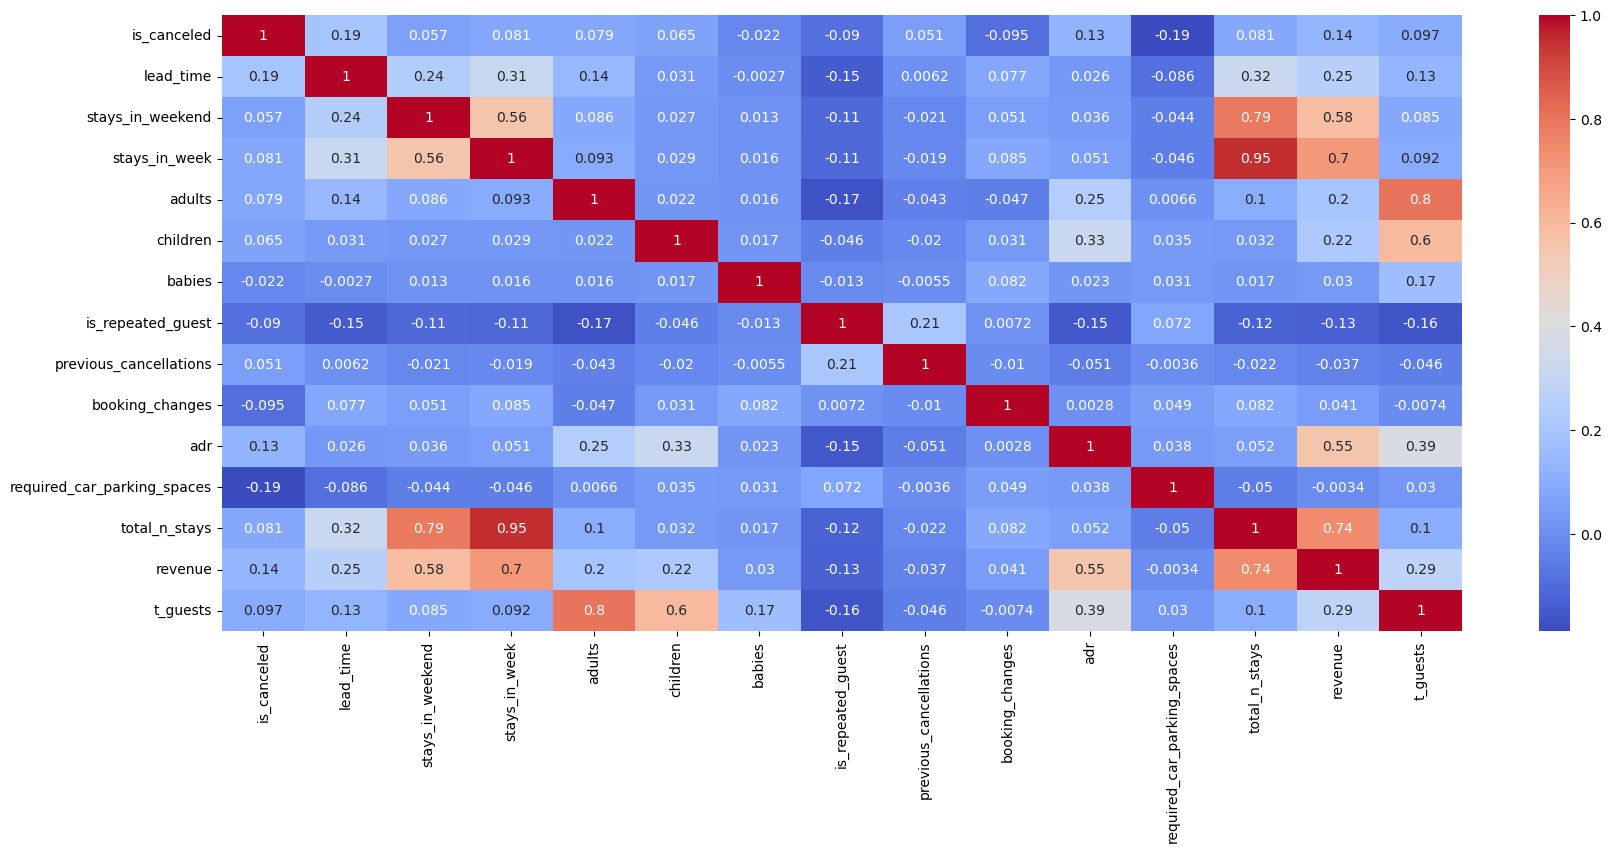

In [183]:
plt.figure(figsize=(20,8))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')

<Axes: xlabel='hotel', ylabel='count'>

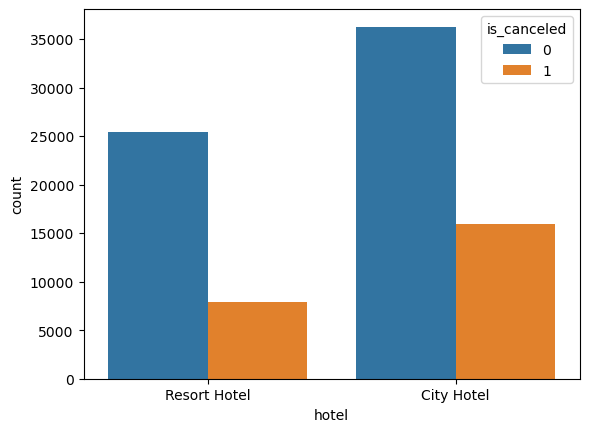

In [192]:
sns.countplot(data = df, x = 'hotel', hue = 'is_canceled')

<Axes: xlabel='meal', ylabel='count'>

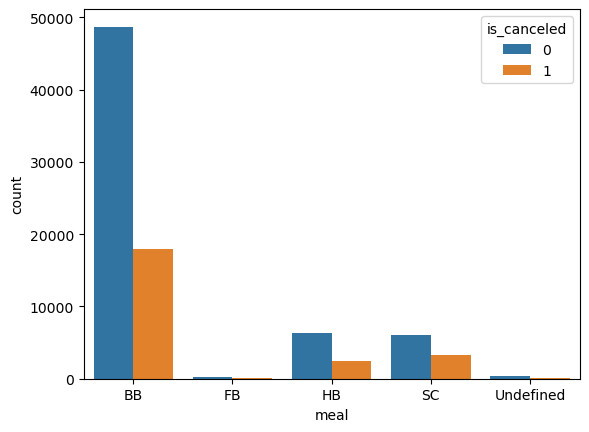

In [193]:
sns.countplot(data = df, x = 'meal', hue = 'is_canceled')

<Axes: xlabel='market_segment', ylabel='count'>

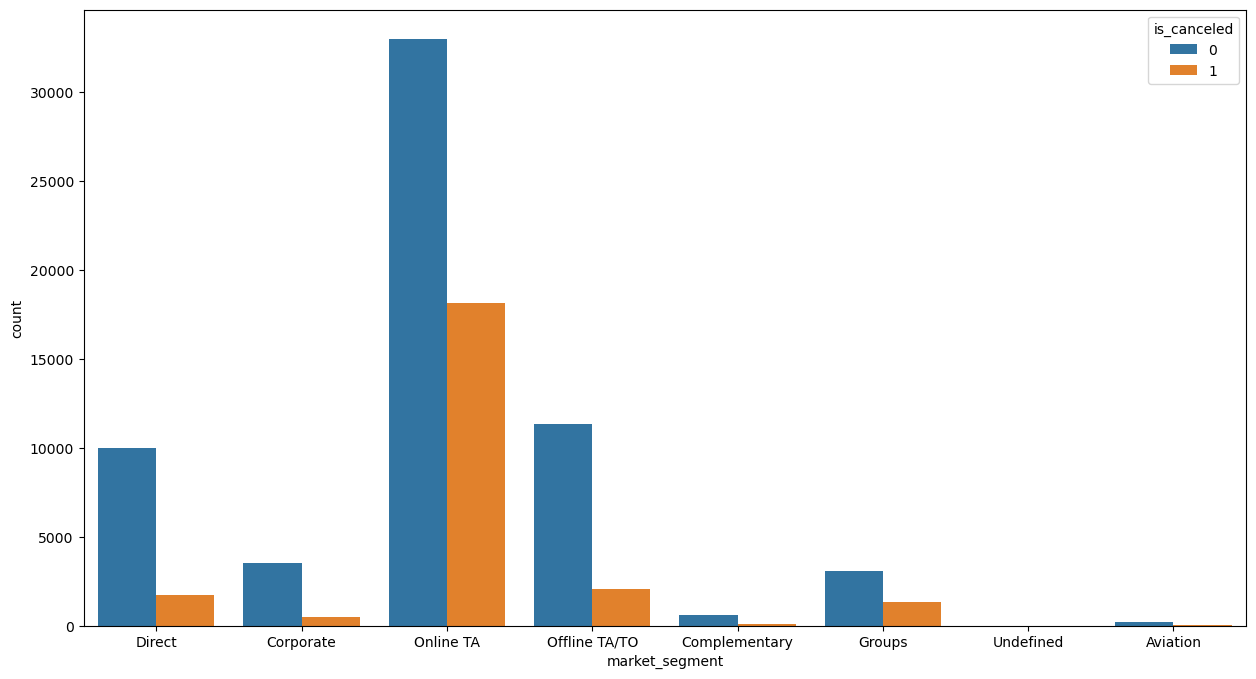

In [194]:
plt.figure(figsize=(15,8))
sns.countplot(data = df, x = 'market_segment', hue = 'is_canceled')

<Axes: xlabel='distribution_channel', ylabel='count'>

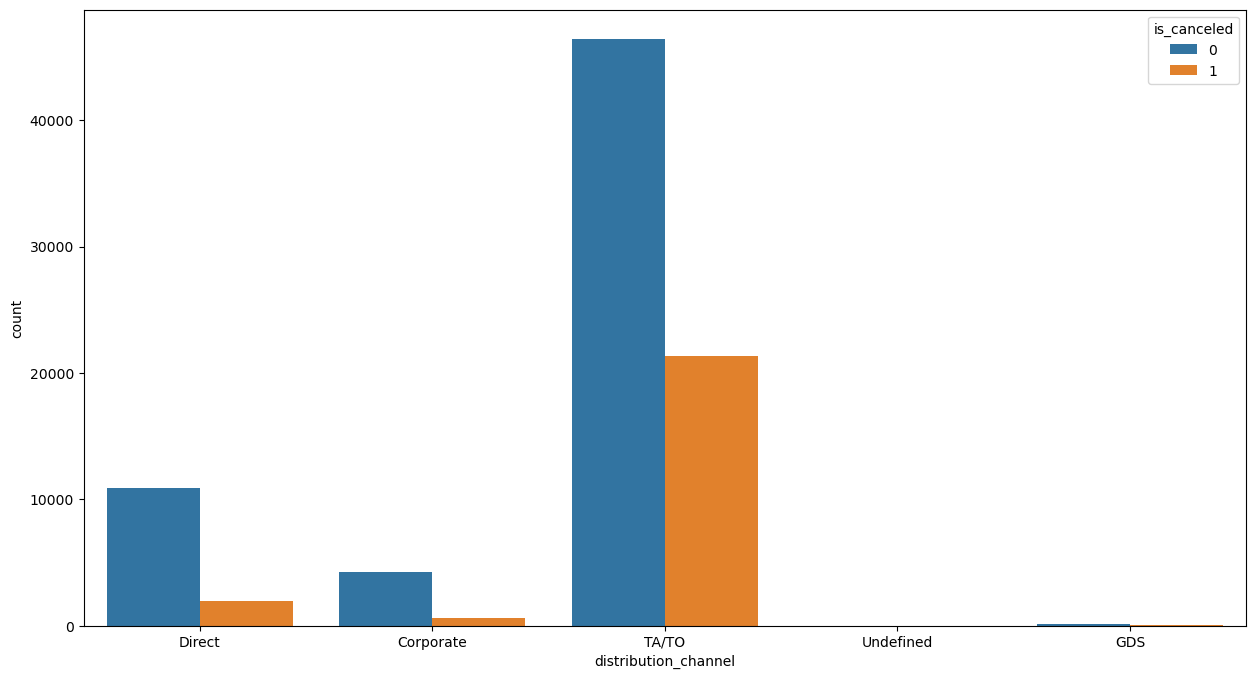

In [196]:
plt.figure(figsize=(15,8))
sns.countplot(data = df, x = 'distribution_channel', hue = 'is_canceled')

<Axes: xlabel='reserved_room_type', ylabel='count'>

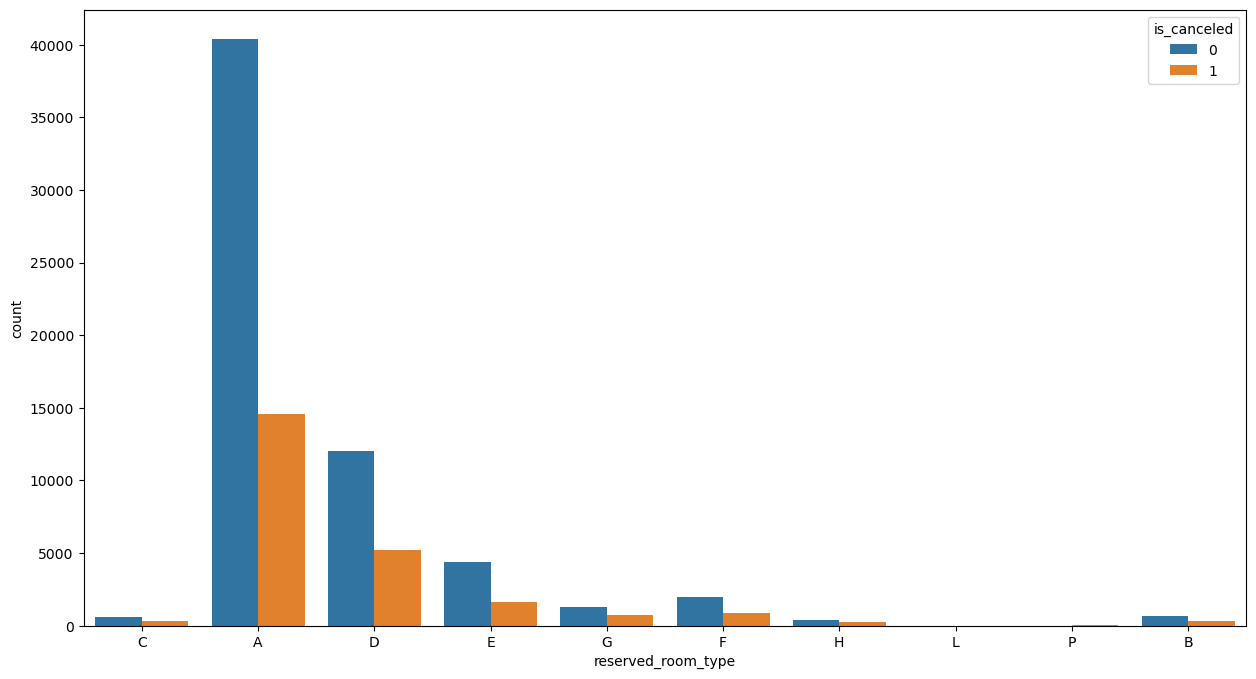

In [197]:
plt.figure(figsize=(15,8))
sns.countplot(data = df, x = 'reserved_room_type', hue = 'is_canceled')

<Axes: xlabel='customer_type', ylabel='count'>

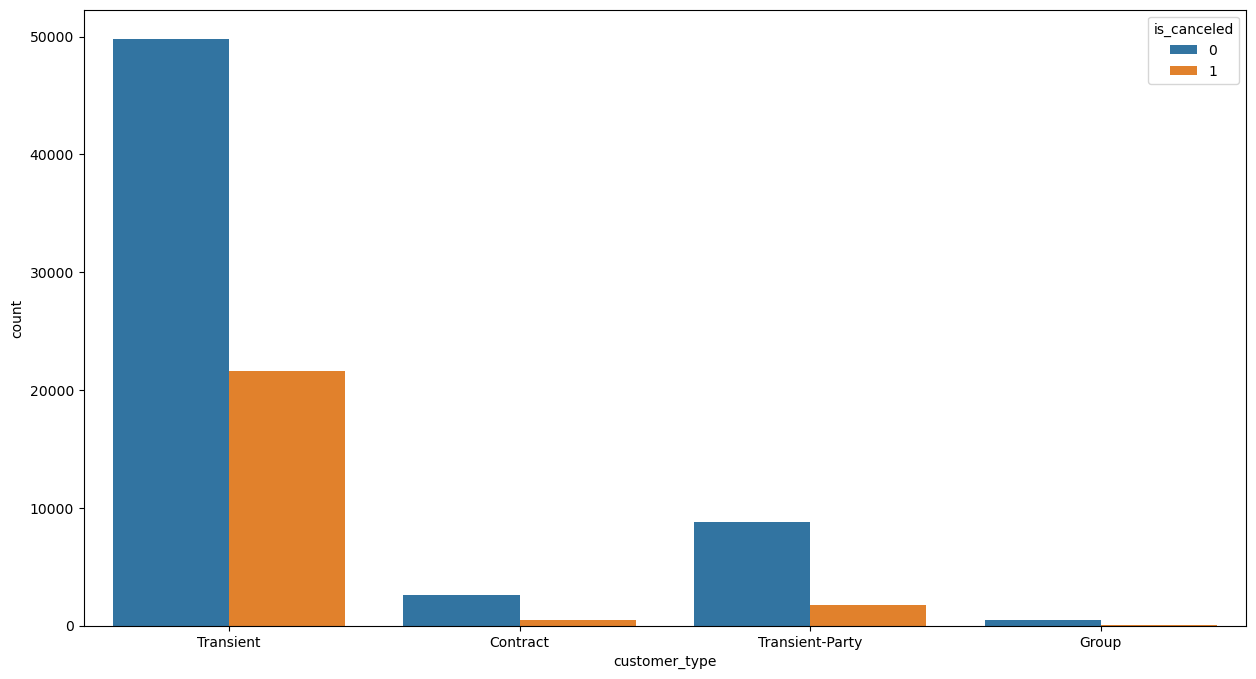

In [198]:
plt.figure(figsize=(15,8))
sns.countplot(data = df, x = 'customer_type', hue = 'is_canceled')

<Axes: xlabel='reservation_status', ylabel='count'>

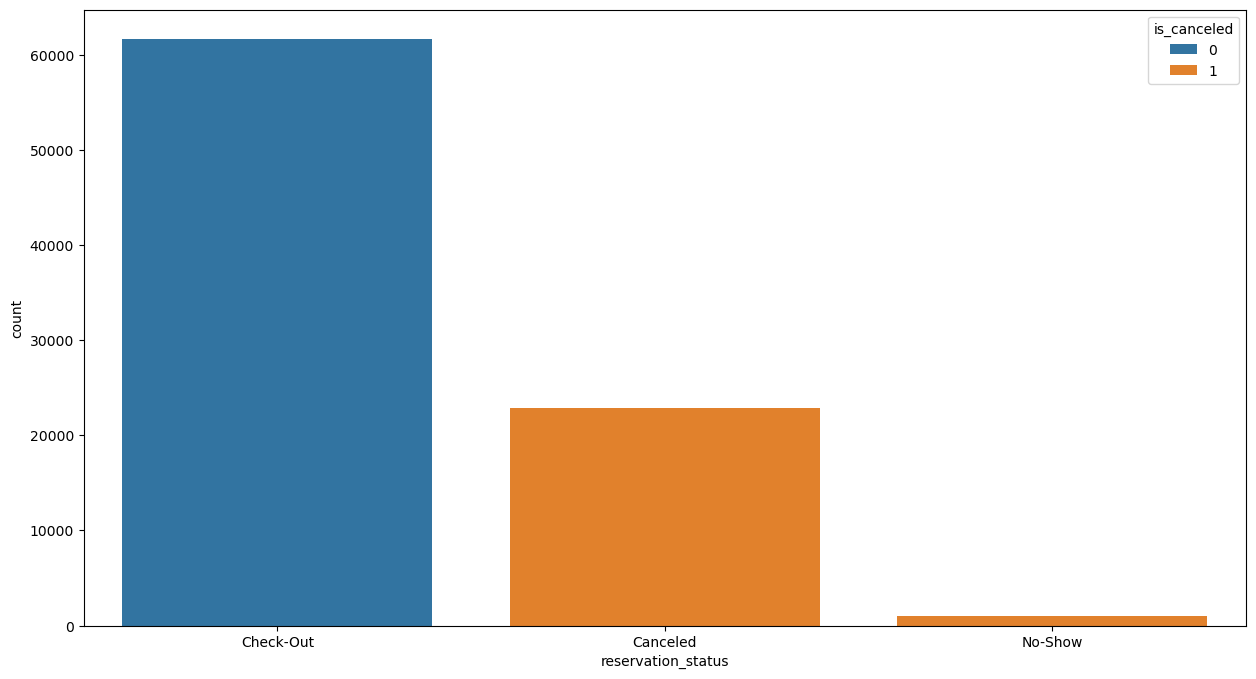

In [199]:
plt.figure(figsize=(15,8))
sns.countplot(data = df, x = 'reservation_status', hue = 'is_canceled')

<Axes: xlabel='country', ylabel='count'>

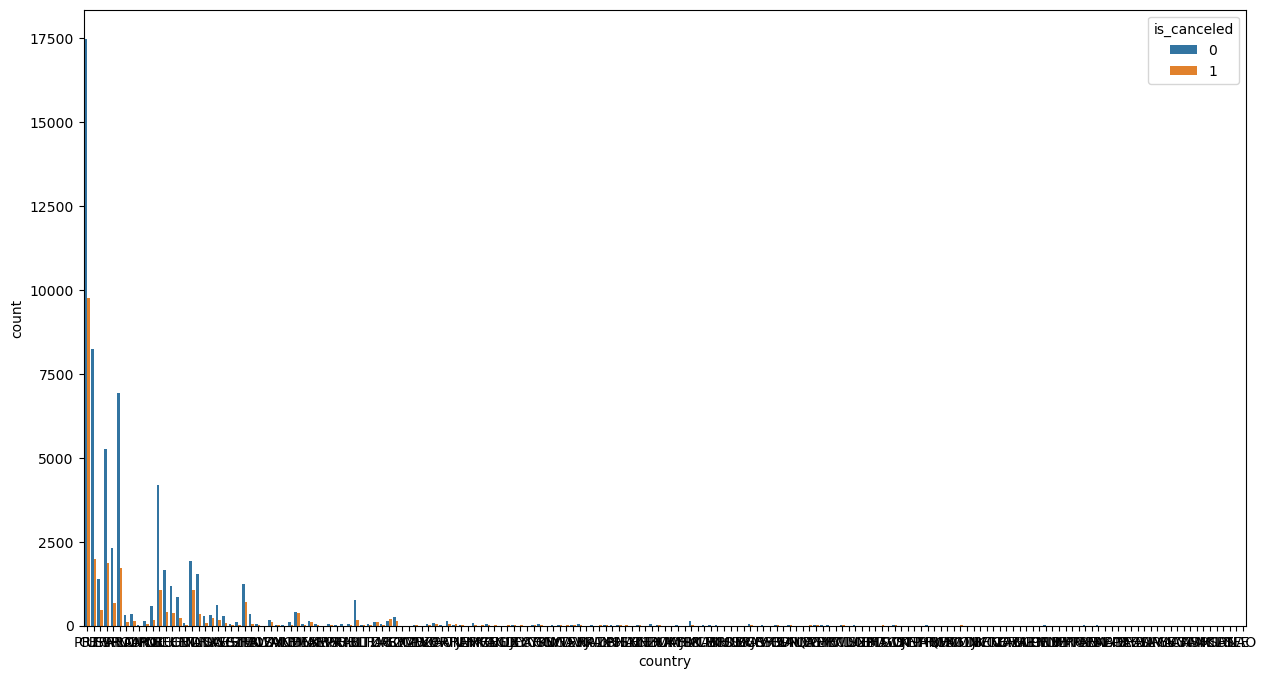

In [200]:
plt.figure(figsize=(15,8))
sns.countplot(data = df, x = 'country', hue = 'is_canceled')

In [201]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['meal_n'] = le.fit_transform(df['meal'])
df['distribution_channel_n'] = le.fit_transform(df['distribution_channel'])

In [202]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
X = df[['n_hotel','n_market_segment','n_reserved_room_type','n_customer_type','lead_time','total_n_stays','previous_cancellations','is_repeated_guest','adr','meal_n','distribution_channel_n','previous_cancellations']]
y = df['is_canceled']
from sklearn.model_selection import  train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
model.fit(X_train,y_train)
model.score(X_test, y_test)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7206286148273646